In [1]:
# Import essential libraries
import os

if 0:
    # Set environment variables for TensorFlow GPU allocator and XLA options
    os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
    os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=off'
    #os.environ['XLA_FLAGS'] = '--xla_gpu_strict_conv_algorithm_picker=false'
    os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
    print("Environment variables for Tensorflow have been set up")
    
import random
import numpy as np
import pandas as pd

In [2]:
# Import TensorFlow for building and training machine learning models
import tensorflow as tf

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth enabled for GPUs")
    except RuntimeError as e:
        print(e)
        
# Import Matplotlib's pyplot module for data visualisation and plotting
import matplotlib.pyplot as plt

# Import Scikit-learn for evaluation metrics such as classification reports
from sklearn.metrics import classification_report

2025-08-31 15:11:39.795566: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-31 15:11:39.804374: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756649499.816261  166252 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756649499.818976  166252 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1756649499.826479  166252 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Memory growth enabled for GPUs


In [3]:
# Import custom loss functions and evaluation metrics for image segmentation tasks
from Components.segmentation_utils import LossFunctions, SegmentationMetrics, SimilarityMetrics

# Import the modified U-Net architecture for segmentation
from Components.unet_models import ModifiedUNet

# Import a custom HN Adam optimiser for training the model
from Components.model_optimisers import HnAdam

In [4]:
# Import project-specific constants and path definitions
from Components.definitions import *

# Print key dataset and file paths for verification
print(f"Dataset path: {DATA_ROOT}")
print(f"Meta path: {Paths.metadata_csv}")
print(f"Mass training data path: {Paths.new_mass_train_csv}")
print(f"Mass test data path: {Paths.new_mass_test_csv}")
print(f"Mass train tensor path: {Paths.mass_train_tensor_dir}")
print(f"Mass test tensor path: {Paths.mass_test_tensor_dir}")

Dataset path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688
Meta path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688/metadata.csv
Mass training data path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688/new_mass_case_description_train_set.csv
Mass test data path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688/new_mass_case_description_test_set.csv
Mass train tensor path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688/mass_tensor/train
Mass test tensor path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688/mass_tensor/test


In [71]:
prefix = 'final_'
history_path = os.path.join(DATA_ROOT, f'{prefix}history.csv')
full_model_path = os.path.join(DATA_ROOT, f'{prefix}mass_model.keras')
best_model_path = os.path.join(DATA_ROOT, f'{prefix}best_mass_model.keras')

# History

### Load history

In [72]:
# Load the training history from the CSV file
history_df = pd.read_csv(history_path)

# Display the last row of the dataframe to see the final training metrics
history_df.tail(1)

,accuracy,dice_coef,jaccard_index,loss,val_accuracy,val_dice_coef,val_jaccard_index,val_loss,fold
999,0.999625,0.961116,0.936195,0.020314,0.999087,0.922815,0.884832,0.04537,9


In [73]:
# Select and display the rows where the validation Dice coefficient or Jaccard index reached their maximum values
history_df.loc[history_df[['val_dice_coef']].idxmax().unique()]

,accuracy,dice_coef,jaccard_index,loss,val_accuracy,val_dice_coef,val_jaccard_index,val_loss,fold
700,0.999529,0.948293,0.918377,0.02714,0.999745,0.981252,0.966066,0.010941,7


### Visualise history

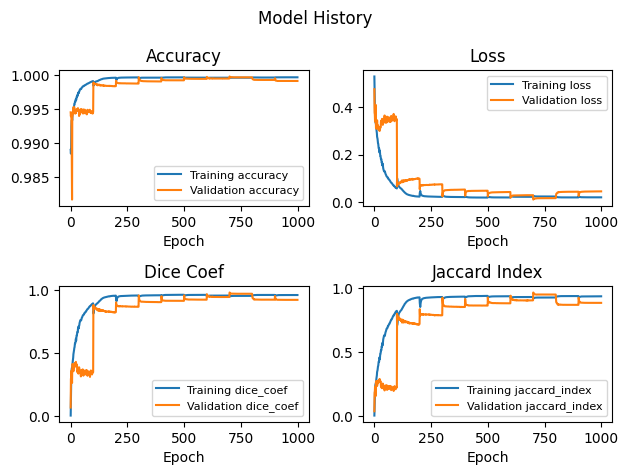

In [74]:
# Visualise the training and validation metrics over epochs using subplots
fig, ax = plt.subplots(2, 2)
fig.suptitle('Model History')
fontsize = 8

# Plot training and validation accuracy
ax[0,0].plot(history_df['accuracy'], label='Training accuracy')
ax[0,0].plot(history_df['val_accuracy'], label='Validation accuracy')
ax[0,0].set_title('Accuracy')
ax[0,0].set_xlabel('Epoch')
ax[0,0].legend(fontsize=fontsize)

# Plot training and validation loss
ax[0,1].plot(history_df['loss'], label='Training loss')
ax[0,1].plot(history_df['val_loss'], label='Validation loss')
ax[0,1].set_title('Loss')
ax[0,1].set_xlabel('Epoch')
ax[0,1].legend(fontsize=fontsize)

# Plot training and validation Dice coefficient
ax[1,0].plot(history_df['dice_coef'], label='Training dice_coef')
ax[1,0].plot(history_df['val_dice_coef'], label='Validation dice_coef')
ax[1,0].set_title('Dice Coef')
ax[1,0].set_xlabel('Epoch')
ax[1,0].legend(fontsize=fontsize)

# Plot training and validation Jaccard index
ax[1,1].plot(history_df['jaccard_index'], label='Training jaccard_index')
ax[1,1].plot(history_df['val_jaccard_index'], label='Validation jaccard_index')
ax[1,1].set_title('Jaccard Index')
ax[1,1].set_xlabel('Epoch')
ax[1,1].legend(fontsize=fontsize)

plt.tight_layout()
plt.show()

# Model

In [75]:
# Load the full saved model from disk.
# Custom objects are included to ensure that the model can be reconstructed
# with the modified U-Net architecture, custom loss functions, metrics, and optimiser.
full_model = tf.keras.models.load_model(
    full_model_path,
    custom_objects={
        'ModifiedUNet': ModifiedUNet,
        'combined_loss': LossFunctions.combined_loss,
        'dice_coef': SegmentationMetrics.dice_coef,
        'jaccard_index': SegmentationMetrics.jaccard_index,
        'HnAdam': HnAdam
    }
)

# Load the best-performing model from disk using the same custom objects.
best_model = tf.keras.models.load_model(
    best_model_path,
    custom_objects={
        'ModifiedUNet': ModifiedUNet,
        'combined_loss': LossFunctions.combined_loss,
        'dice_coef': SegmentationMetrics.dice_coef,
        'jaccard_index': SegmentationMetrics.jaccard_index,
        'HnAdam': HnAdam
    }
)

Config passed to from_config: {'name': 'modified_u_net', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'input_shape': [128, 128, 3]}
Config passed to from_config: {'name': 'modified_u_net', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'input_shape': [128, 128, 3]}


### Model summary

In [76]:
# Display the architecture summary of the loaded model
full_model.summary()

Model: "modified_u_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Modified_U-Net (Functional)     │ (None, 128, 128, 1)    │    34,513,345 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,053,386 (526.63 MB)

 Trainable params: 34,513,345 (131.66 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 103,540,041 (394.97 MB)

### Evaluation

In [77]:
# Load the test dataset from saved TensorFlow dataset directory
test_images = tf.data.Dataset.load(Paths.mass_test_tensor_dir)

# Print the shape of one sample image and its mask from the test dataset
for x, y in test_images.take(1):
    print(f"test image shape: {x.shape}, {y.shape}")

# Calculate the total number of test samples
test_rows = len(test_images)

# Define the size of the validation subset (80% of test data)
val_size = int(0.8 * test_rows)

# Calculate the remaining test subset size
test_size = test_rows - val_size

# Define batch size for evaluation
BATCH_SIZE = 8

# Prepare the test batches by skipping validation samples, taking the test subset, and batching them for evaluation
test_batches = (
    test_images
    .skip(val_size)
    .take(test_size)
    .batch(BATCH_SIZE)
)

test image shape: (128, 128, 3), (128, 128, 1)


In [78]:
# Evaluate the loaded model on the prepared test batches and store the results
evaluations = best_model.evaluate(test_batches)

print("Evaluation with test dataset:")
print(f"\tLoss: {evaluations[0]:.4f}")
print(f"\tAccuracy: {evaluations[1] * 100:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.9997 - dice_coef: 0.9466 - jaccard_index: 0.9167 - loss: 0.0285
Evaluation with test dataset:
	Loss: 0.0163
	Accuracy: 99.98%


### Prediction

In [79]:
# Generate predictions from the loaded model on the test batches
predictions = best_model.predict(test_batches)

# Print the shape of the predictions array
print(f"predictions size: {predictions.shape}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
predictions size: (76, 128, 128, 1)


In [80]:
# Initialise lists to collect all true and predicted pixels
y_true_all = []
y_pred_all = []

# Iterate over batches in the test dataset
for images, masks in test_batches:
    # Predict masks for current batch
    preds = best_model.predict(images)  # Shape: (batch, 128, 128, 1)

    # Threshold predictions to get binary masks
    preds = (preds > 0.5).astype(np.uint8)

    # Flatten ground truth masks and predictions, convert to integers, and append to lists
    y_true_all.extend(masks.numpy().flatten().astype(np.uint8))
    y_pred_all.extend(preds.flatten())

# Print detailed classification report with precision, recall, f1-score for each class
print(classification_report(y_true_all, y_pred_all))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1238900
           1       0.98      0.98      0.98      6284

    accuracy                           1.00   1245184
   macro avg       0.99      0.99      0.99   1245184
weighted avg       1.00      1.00      1.00   1245184



In [81]:
def display(images):
    """
    Display a list of images side-by-side with titles:
    'Input Image', 'Ground Truth', and 'Predicted Mask'.

    Args:
        images (list): List of images/tensors to display.
    """
    plt.figure(figsize=(5, 5))

    # Set titles: defaults to GT and Prediction, adds Input if given
    title = ["Ground Truth", "Predicted Mask"]
    if len(images) == 3:
        title.insert(0, "Input Image")
    
    # Loop over each image and plot it in a subplot
    for i in range(len(images)):
        plt.subplot(1, len(images), i+1)
        plt.title(title[i], fontsize=10)
        plt.imshow(tf.keras.utils.array_to_img(images[i])) # Convert tensor to image
        plt.axis("off") # Hide axis for clarity
    plt.show()
    
def create_mask(pred_mask, index=0):
    """
    Convert a predicted mask tensor into a binary mask by thresholding.

    Args:
        pred_mask (tf.Tensor): The predicted mask(s) from the model.
        index (int): The index of the mask to return (in case of batch).

    Returns:
        tf.Tensor: Binary mask tensor.
    """
    # Threshold prediction at 0.5 to get binary mask
    mask = tf.cast(pred_mask > 0.5, tf.uint8)

    # Return the first mask (remove batch dim)
    return mask[index]

Index: 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


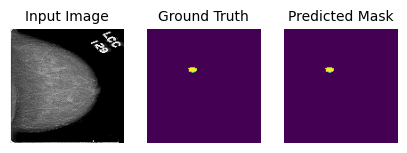

Index: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


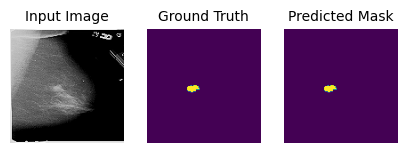

Index: 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


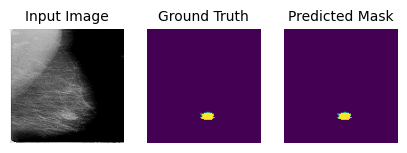

Index: 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


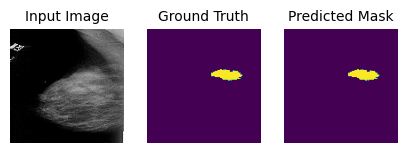

Index: 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


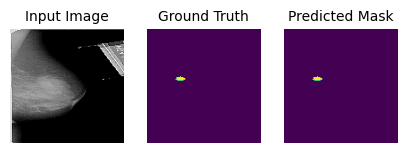

Index: 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


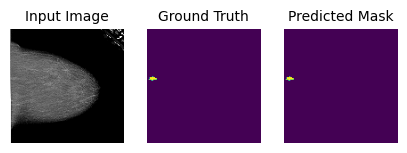

Index: 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


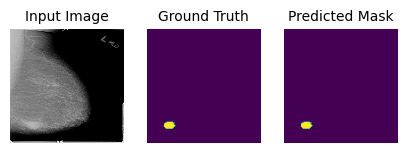

Index: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


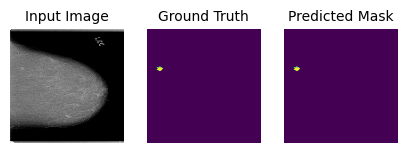

Index: 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


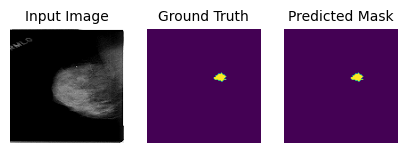

Index: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


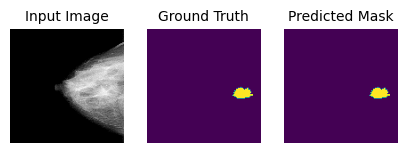

In [82]:
# Number of images/batches to display
image_number = len(test_batches)

# Iterate through the first 'image_number' batches of test data
for image, mask in test_batches.take(image_number):
    idx = random.randint(0, len(image)-1)
    print(f"Index: {idx}")
          
    full_image = image[idx]
    true_mask = mask[idx] # Take the first mask in the batch (ground truth)
    pred_mask = best_model.predict(image) # Predict mask for the batch
    pred_mask = create_mask(pred_mask, idx)

    # Display input image, true mask, and predicted mask side by side
    display([full_image, true_mask, pred_mask])

#for image, mask in test_batches.shuffle(1000).take(image_number):

### Similarity

In [83]:
# Number of images/batches to display
image_number = len(test_batches)

# Initialise counters for total images and masks
num_images = 0
num_masks = 0

# Count total images and masks in the test batches
for image, mask in test_batches.take(image_number):
    num_images = num_images + len(image) # Add number of images in this batch
    num_masks = num_masks + len(mask) # Add number of masks in this batch
    
print(f"Total: {num_images} images, {num_masks} masks")
print(f"Test size: {test_size} / Validation size: {val_size} (Sum: {test_size + val_size})")

# Store cases where similarity or accuracy is not perfect
near_perfect_matching_cases = [] # 99.99% <= score < 100%
critical_warning_cases = [] # score < 99.99%

# Iterate through the test data batch by batch
for image, mask in test_batches.take(image_number):
    for idx in range(len(image)):
        # Predict mask for the entire batch
        pred_mask = best_model.predict(image)
        
        # Get the binary mask for the current index in the batch
        pred_mask = create_mask(pred_mask, idx)
        
        # Get the corresponding ground truth mask
        true_mask = mask[idx]

        # Compute histogram similarity score
        similarity_score = SimilarityMetrics.get_histogram_similarity(true_mask, pred_mask)
        
        # Compute pixel-wise accuracy
        pixelwise_accuracy = SimilarityMetrics.get_pixel_accuracy(true_mask, pred_mask)
        
        # Flag suspicious or imperfect predictions
        if similarity_score == 100 and pixelwise_accuracy == 100:
            # Perfect match — just print
            continue
        if similarity_score < 99.99 or pixelwise_accuracy < 99.99:
            # Significant mismatch
            critical_warning_cases.append([true_mask, pred_mask, similarity_score, pixelwise_accuracy])
        else:
            # Very high but imperfect match
            near_perfect_matching_cases.append([true_mask, pred_mask, similarity_score, pixelwise_accuracy])

Total: 76 images, 76 masks
Test size: 76 / Validation size: 302 (Sum: 378)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━

### Critical warning cases
Cases in which the histogram-based similarity or pixel-wise accuracy is below 99.99%. Typically, this indicates that the predicted mask is often empty while the ground truth contains relevant regions, or the predicted mask includes additional areas that do not correspond to the ground truth.

Critical warning cases account for 6.58% of the total test cases

similarity score: 100.0%, pixel-wise accuracy: 99.68%


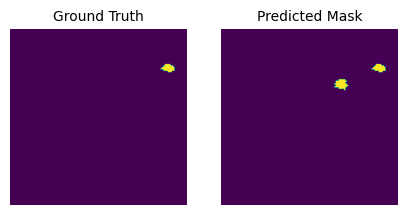

similarity score: 100.0%, pixel-wise accuracy: 99.75%


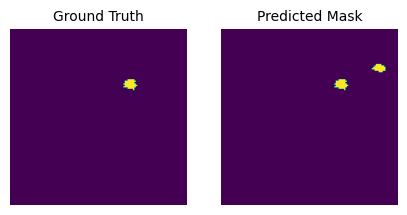

similarity score: 0.0%, pixel-wise accuracy: 99.78%


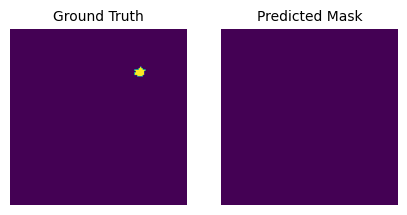

similarity score: 0.0%, pixel-wise accuracy: 99.82%


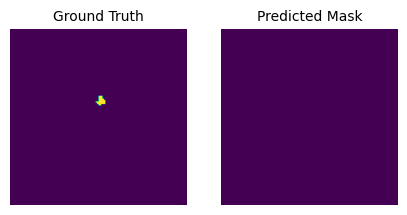

similarity score: 0.0%, pixel-wise accuracy: 99.61%


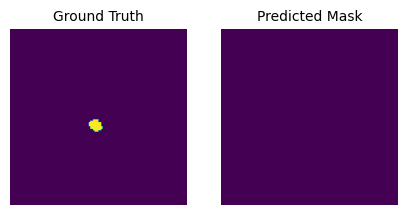

In [84]:
print(f"Critical warning cases account for {round(len(critical_warning_cases)/test_size * 100, 2)}% of the total test cases\n")

for case in critical_warning_cases:
    true_mask = case[0]
    pred_mask = case[1]
    similarity = case[2]
    accuracy = case[3]
    
    print(f"similarity score: {similarity}%, pixel-wise accuracy: {accuracy}%")
    display([true_mask, pred_mask])

### Near-perfect matching cases
Cases with similarity or pixel accuracy above 99.99% but below 100%, indicating small differences with no meaningful effect on the mask match.

Near-perfect matching cases account for 5.26% of the total test cases

similarity score: 100.0%, pixel-wise accuracy: 99.99%


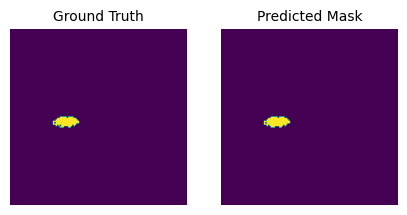

similarity score: 100.0%, pixel-wise accuracy: 99.99%


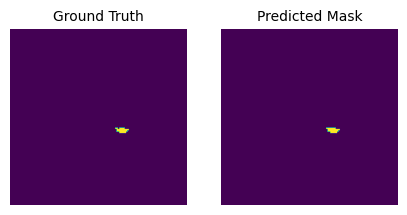

similarity score: 100.0%, pixel-wise accuracy: 99.99%


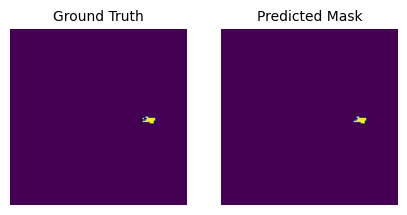

similarity score: 100.0%, pixel-wise accuracy: 99.99%


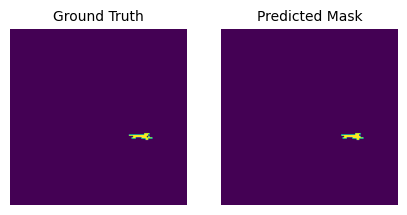

In [85]:
print(f"Near-perfect matching cases account for {round(len(near_perfect_matching_cases)/test_size * 100, 2)}% of the total test cases\n")

for case in near_perfect_matching_cases:
    true_mask = case[0]
    pred_mask = case[1]
    similarity = case[2]
    accuracy = case[3]
    
    print(f"similarity score: {similarity}%, pixel-wise accuracy: {accuracy}%")
    display([true_mask, pred_mask])